# 31회차 기출문제


## 문제 1

**Data description**

개인의 헬스케어 데이터를 활용하여 비만 수준을 예측하는 문제입니다.

-   **Gender** : 성별

-   **Age** : 나이

-   **Height** : 키

-   **Weight** : 몸무게

-   **family_history_with_overweight** : 가족 중 과체중인 사람이 있는지 여부

-   **FAVC** : 고칼로리 식품을 자주 섭취하는지 여부

-   **FCVC** : 채소 섭취 빈도

-   **NCP** : 식사 횟수

-   **CAEC** : 간식 섭취 빈도

-   **SMOKE** : 흡연 여부

-   **CH20** : 물 섭취 양

-   **SCC** : 섭취 칼로리를 모니터링하는지 여부

-   **FAF** : 운동 빈도

-   **TUE** : 전자제품(휴대폰, TV, 비디오게임 등) 사용 빈도

-   **CALC** : 알코올 섭취 빈도

-   **MTRANS** : 주로 이용하는 교통 수단

-   **NObeyesdad** : 비만 수준

    -   overweight_level_i : 과체중 수준 i
    -   obesity_type_i : 비만 유형 i
    -   obesity_type_ii : 비만 유형 ii
    -   obesity_type_iii : 비만 유형 iii

1.  **데이터 분포를 살펴보고 특성을 기술하시오.**

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import warnings

warnings.filterwarnings('ignore')

dt1 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/31/problem1.csv')
dt1 = dt1[dt1.columns[1:]]
print(dt1.info())
dt1.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1262 entries, 0 to 1261
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1262 non-null   object 
 1   Gender                          1262 non-null   object 
 2   Age                             1262 non-null   int64  
 3   Height                          1262 non-null   float64
 4   Weight                          1262 non-null   int64  
 5   family_history_with_overweight  1262 non-null   object 
 6   FAVC                            1262 non-null   object 
 7   FCVC                            1262 non-null   object 
 8   NCP                             1262 non-null   int64  
 9   CAEC                            1262 non-null   object 
 10  SMOKE                           1262 non-null   object 
 11  CH2O                            1262 non-null   object 
 12  SCC                             12

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,4,male,27,1.80,87,no,no,always,3,sometimes,no,between 1 and 2 l,no,2 to 4,0 to 2,frequently,walking,overweight_level_i,26.851852
1,11,male,26,1.85,105,yes,yes,always,3,frequently,no,more than 2 l,no,2 to 4,>5,sometimes,public_transportation,obesity_type_i,30.679328


In [37]:
dt1.isna().sum()/len(dt1)

id                                0.000000
Gender                            0.000000
Age                               0.000000
Height                            0.000000
Weight                            0.000000
family_history_with_overweight    0.000000
FAVC                              0.000000
FCVC                              0.000000
NCP                               0.000000
CAEC                              0.000000
SMOKE                             0.000000
CH2O                              0.000000
SCC                               0.002377
FAF                               0.000000
TUE                               0.000000
CALC                              0.000000
MTRANS                            0.000000
NObeyesdad                        0.000000
BMI                               0.000000
dtype: float64

SCC(섭취 칼로리 모니터링 여부)에서 0.0023%의 결측치가 존재한다. 각

In [38]:
# 데이터 분포 확인
#1.수치형
print("수치형 변수 분포:")
display(dt1.describe(include='number').T)
#2. 카테고리형

print("카테고리형 변수 분포:")
display(dt1.describe(include='O').T)

수치형 변수 분포:


,count,mean,std,min,25%,50%,75%,max
Age,1262.0,25.749604,9.898088,15.000000,21.000000,24.000000,27.000000,150.000000
Height,1262.0,1.709184,0.091361,1.450000,1.631576,1.711095,1.775768,1.980000
Weight,1262.0,101.083201,21.520848,53.000000,82.000000,105.000000,116.000000,173.000000
NCP,1262.0,2.665610,0.757143,1.000000,3.000000,3.000000,3.000000,4.000000
BMI,1262.0,34.439463,6.106623,22.826739,30.725995,34.332001,38.920119,50.811753


카테고리형 변수 분포:


,count,unique,top,freq
id,1262,1262,"2,032",1
Gender,1262,2,male,636
family_history_with_overweight,1262,2,yes,1173
FAVC,1262,2,yes,1221
FCVC,1262,3,always,630
CAEC,1262,4,sometimes,1190
SMOKE,1262,2,no,1237
CH2O,1262,3,between 1 and 2 l,618
SCC,1259,2,no,1219
FAF,1262,4,1 to 2,482


<범주형 변수 분포>


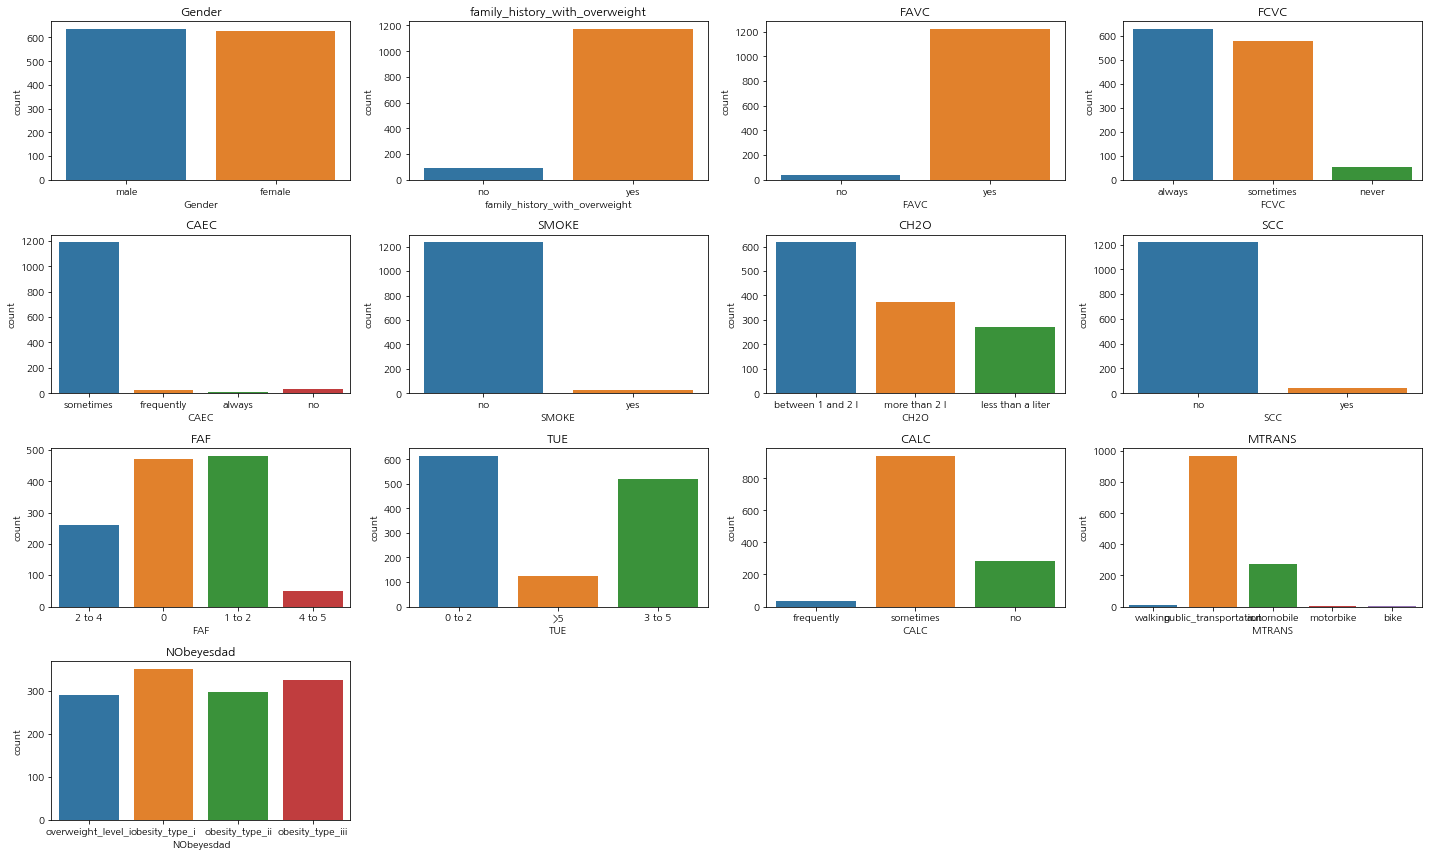

<수치형 변수 분포>


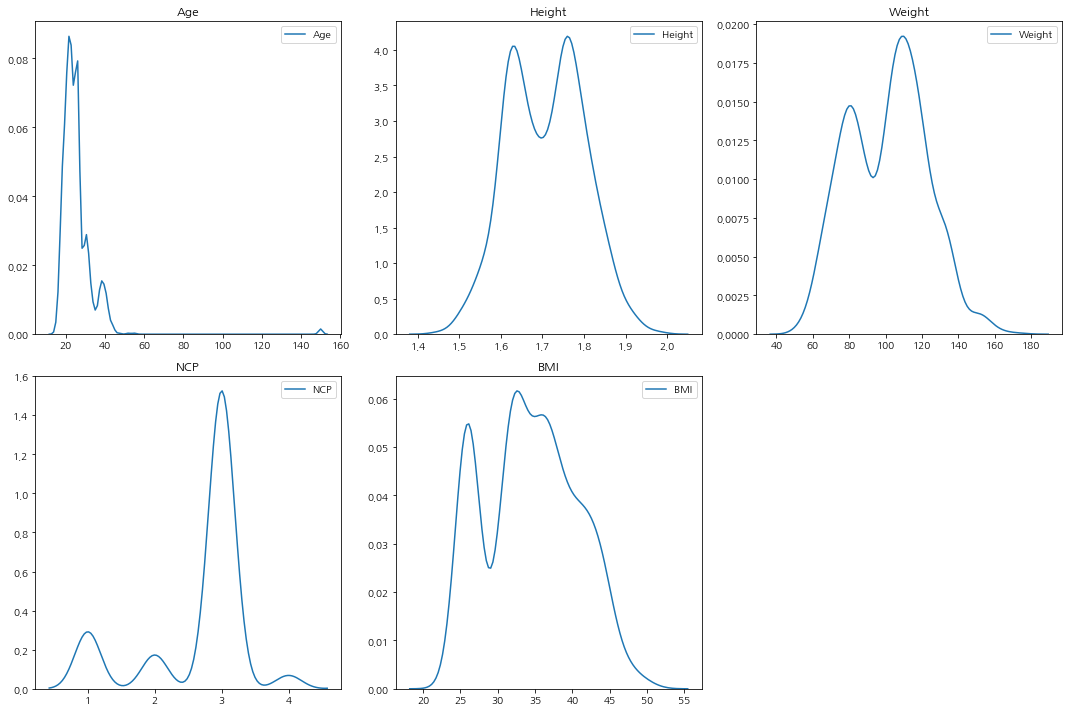

In [39]:
# 분포 시각화
c_cols = dt1.select_dtypes(include='O').columns[1:]
n_cols = dt1.select_dtypes(include='number').columns

print("<범주형 변수 분포>") # 14
fig, ax = plt.subplots(4, 4, figsize=(20, 12))

for i, col in enumerate(c_cols):
    x = i // 4
    y = i % 4
    sns.countplot(dt1[col], ax=ax[x, y])
    ax[x, y].set_title(col)
ax[3, 1].remove()
ax[3, 2].remove()
ax[3, 3].remove()
plt.tight_layout()
plt.show()
print("<수치형 변수 분포>") #

fig, ax = plt.subplots(2, 3, figsize=(15, 10))

for i, col in enumerate(n_cols):
    x = i // 3
    y = i % 3
    sns.kdeplot(dt1[col], ax=ax[x, y])
    ax[x, y].set_title(col)
ax[1, 2].remove()
plt.tight_layout()
plt.show()

- 범주형 변수 분포
  - 성별의 경우 남성과 여성이 균등한 분포를 보임
  - family_history_with_overweight(가족 중 과체중인 사람이 있는지 여부)는 yes인 사람이 no인 사람에 비해 확연히 많음
  - FAVC(고칼로리 식품을 자주 섭취하는지 여부)도 yes인 사람이 no인 사람에 비해 확연히 많음
  - FCVC : 채소 섭취 빈도는 always>sometimes>never 순이며, never가 차지하는 비율이 낮음
  - CAEC : 간식 섭취 빈도는 sometimes가 차지하는 비율이 가장 높음
  - SMOKE : 흡연 여부는 비흡연자의 비율이 현저히 높음
  - H20 : 물 섭취 양은 1-2사이가 가장 많음
  - SCC : 섭취 칼로리를 모니터링하는지 여부는 no가 현저히 높음
  - FAF : 운동 빈도는 1-2, 0 순으로 비율이 높음
  - TUE : 전자제품(휴대폰, TV, 비디오게임 등) 사용 빈도는 0-2, 3-5 순으로 높음
  - CALC : 알코올 섭취 빈도는 가끔씩이 가장 높으며, 자주가 가장 낮음
  - MTRANS : 주로 이용하는 교통 수단은 대중교통 비율이 가장 높으며, 그 다음으로 차량이 높음
  - NObeyesdad : 비만 수준은 대체로 균등하며, obesity_type_i : 비만 유형 i이 가장 높음
  
- 수치형(연속형) 변수 분포
  - 나이는 20대의 비율이 높으며, 양의 왜도가 높음(좌측으로 치우치며, 우측으로 긴 꼬리)
  - 키는 1.6, 1.8의 비율이 높으며, 이봉분포를 보임
  - 몸무게는 약 110의 비율이 가장 높음
  - NCP : 식사 횟수는 3번(매끼니)의 비율이 가장 높으며, 음의 왜도(우측으로 치우침)를 보임
  - bmi는 30-35사이의 비율이 가장 높음

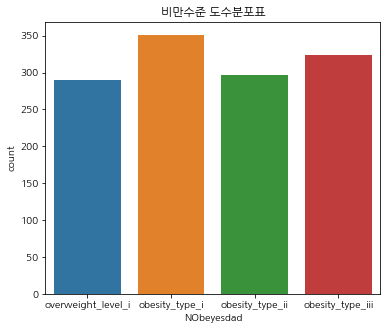

In [40]:
# 비만수준 count plot

plt.figure(figsize=(6, 5))
sns.countplot(dt1['NObeyesdad'])
plt.title("비만수준 도수분포표")
plt.show()

In [41]:
dt1 = dt1[dt1.columns[1:]] #불필요 변수 id 삭제

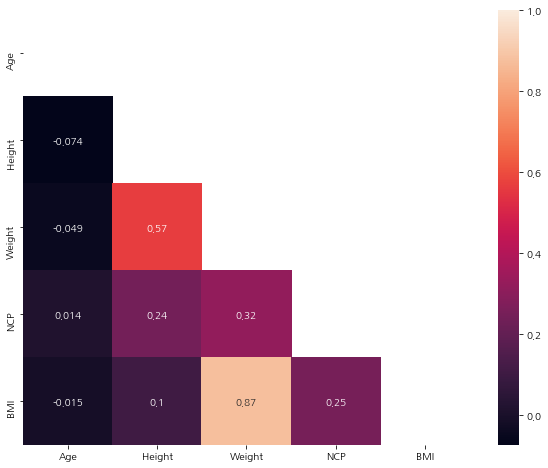

In [42]:
plt.figure(figsize=(10, 8))
corr = dt1.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

수치형 변수를 활용해 선형 상관관계를 확인하였다.(pearson corr 사용)  
몸무게와 BMI 간 0.87로 비교적 강한 양의 상관관계를 확인할 수 있으며, 키와 몸무게 간에도 0.57로 다소 높은 양의 상관관계가 있다.  

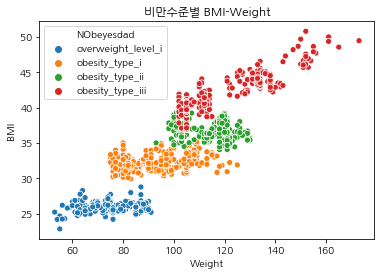

In [101]:
sns.scatterplot(x='Weight', y='BMI',  hue='NObeyesdad', data=dt1)
plt.title("비만수준별 BMI-Weight")
plt.show()

BMI 값에 따라 비만수준별 분류가 나뉘는 것을 볼 수 있다.

In [51]:
dt1[dt1.isna().any(axis=1)]

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
361,male,26,1.837117,106,yes,yes,always,3,sometimes,no,more than 2 l,NaN,2 to 4,>5,sometimes,public_transportation,obesity_type_i,31.322149
675,male,25,1.885543,121,yes,yes,sometimes,3,sometimes,no,more than 2 l,NaN,1 to 2,0 to 2,sometimes,public_transportation,obesity_type_ii,34.105146
1100,female,20,1.792833,152,yes,yes,always,3,sometimes,no,between 1 and 2 l,NaN,1 to 2,3 to 5,sometimes,public_transportation,obesity_type_iii,47.424943


2.  **데이터 전처리 기법 2가지를 기술하고, 해당 기법이 어떤 효과가 있는지 설명하시오.**

1. 결측치 처리: 대푯값 대치, 결측치 제거

| 방법        | 장점                          | 단점                               |
| --------- | --------------------------- | -------------------------------- |
| 결측값 삭제    | - 처리 간단<br>- 분석 왜곡 없이 정제 가능 | - 데이터 손실 발생<br>- 결측치가 많으면 정보 부족  |
| 평균/중앙값 대체 | - 데이터 보존 가능<br>- 간단하고 빠름    | - 분산 감소<br>- 왜곡된 값으로 모델 성능 저하 가능 |
| 모델 기반 대체  | - 변수 간 관계 반영 가능             | - 복잡함<br>- 추가 모델링 필요             |

**SCC는 범주형 데이터이며, 특정 빈도가 확연히 높으므로 최빈값으로 대치를 고려할 수 있으며, 해당 결측치를 삭제할 수도 있다.**  
- 최빈값 대치: 데이터를 보존할 수 있으며, 간단하고 빠르나, 실제 값이 아닌 대치값이므로 모델의 왜곡을 일으킬 수 있다.  
- 결측값 삭제: 처리가 간단하며 분석의 왜곡 없이 정제가 가능하나, 결측비율이 높을 경우 데이터 손실이 발생하여 제대로 된 모델학습이 안될 수 있음

 2. 스케일링: Standard Scaler 
 
| 기법             | 장점                                        | 단점                                |
| -------------- | ----------------------------------------- | --------------------------------- |
| StandardScaler | - 이상치에 강함<br>- 정규분포 가정 모델에 적합 (회귀, PCA 등) | - 비정규분포에서는 왜곡 가능                  |
| MinMaxScaler   | - 간단하고 직관적<br>- 모든 값이 0\~1 범위             | - 이상치에 민감<br>- 이상치가 있으면 전체 스케일 왜곡 |
| RobustScaler   | - 이상치에 강함 (중앙값, IQR 사용)                   | - 표준화된 분포 아님<br>- 해석이 직관적이지 않음    |

**스케일링은 연속형 변수의 각기 다른 스케일을 정규분포 가정하여 -1~1사이값으로 맞춤으로써(평균0, 분산1) 모델의  
  다양한 기계학습 알고리즘(특히 선형회귀, 로지스틱 회귀, SVM, KNN, PCA 등)의 학습 안정성과 정확도를 높이는데 효과적**
  - 각 변수의 단위 차이를 제거하여 모델 학습이 특정 변수에 치우치지 않도록 함
  - 경사하강법 기반 알고리즘의 수렴 속도 개선
  - 거리 기반 알고리즘(KNN, SVM 등)에서 필수적

**결측치 삭제, standard scaler 채택**

In [52]:
dt1 = dt1.dropna()

2.  **이상치 처리**

In [53]:
dt1.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
Age,1259.0,25.754567,9.908531,15.000000,21.000000,24.000000,27.000000,150.000000
Height,1259.0,1.708876,0.091233,1.450000,1.631439,1.710616,1.775582,1.980000
Weight,1259.0,101.023034,21.490752,53.000000,82.000000,105.000000,116.000000,173.000000
NCP,1259.0,2.664813,0.757869,1.000000,3.000000,3.000000,3.000000,4.000000
BMI,1259.0,34.431891,6.102283,22.826739,30.715939,34.343740,38.919026,50.811753


Age 이상치: 117
Height 이상치: 0
Weight 이상치: 1
NCP 이상치: 42
BMI 이상치: 0


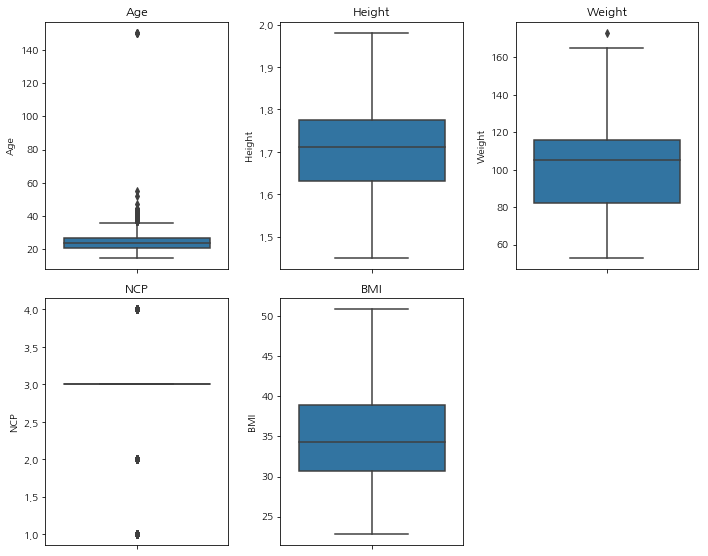

In [67]:
#iqr 활용(수치형 데이터)
tmp = dt1.describe(include='number').T

# 이상치에 해당하는 컬럼별 갯수
for i, col in enumerate(n_cols):
    q1 = tmp['25%'][col]
    q3 = tmp['75%'][col]
    iqr = q3 - q1
    up = q3 + 1.5*iqr
    down = q1 = 1.5*iqr
    cnt = len(dt1[(dt1[col] < down) | (dt1[col] > up)])
    print(f"{col} 이상치: {cnt}")
    
fig, ax = plt.subplots(2, 3, figsize=(10, 8))
for i, col in enumerate(n_cols):
    x = i // 3
    y = i % 3
    sns.boxplot(y=dt1[col], ax=ax[x, y])
    ax[x, y].set_title(col)
plt.tight_layout()
ax[1, 2].remove()
plt.show()

사분위수 기준으로 3개의 변수에서 이상치가 판별되었다.  
이 중 Age는 1개의 극단적인 이상치(150세)를 제외한 나머지는 현실적으로 가능한 관찰값이므로 제거하지 않는다.  
몸무게 또한 이상치가 상한값과 가까우므로 보간이나 삭제하지 않고, 식사횟수 또한 마찬가지로 1, 2, 4끼를 먹는 사람이 현실적으로  
있을 수 있으므로 삭제하지 않는다.

In [69]:
dt1 = dt1[dt1['Age'] != 150]

3.  **주어진 데이터를 확인하고, 파생변수를 1개 생성하시오.**
- 앞서 BMI값에 따라 비만여부 분류가 나뉘는 것을 볼 수 있다. 이를 통해 BMI별로 구간을 분류하여 비만정도를 나타내는 파생변수를 생성한다.

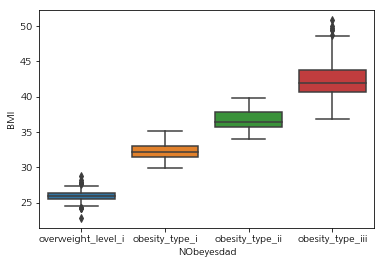

In [102]:
sns.boxplot(x='NObeyesdad', y='BMI', data=dt1)
plt.show()

In [106]:
tt = dt1.groupby('NObeyesdad')['BMI'].agg(
    min = 'min', 
    q1 = lambda x: x.quantile(0.25),
    mean = 'mean', 
    median = 'median', 
    q3 = lambda x: x.quantile(0.75),
    max = 'max'
)
tt

,min,q1,mean,median,q3,max
NObeyesdad,,,,,,
obesity_type_i,29.911958,31.402133,32.260083,32.203812,32.973741,35.171095
obesity_type_ii,34.048509,35.753610,36.732270,36.418410,37.884250,39.786652
obesity_type_iii,36.774400,40.607079,42.274572,41.942617,43.837706,50.811753
overweight_level_i,22.826739,25.574891,25.988723,25.971277,26.387981,28.769607


overweight_level_i의 최대값은 28.769607인데, obesity_type들의 최소값은 이보다 작으므로 이 두 클래스를 이 값을 사용해서 분류할 수 있다.  
obesity_type_i과 obesity_type_ii는 일부 값이 겹치지만 obesity_type_i의 최대값인 35.171095를 기준으로 대체로 분류된다.  
obesity_type_ii과 obesity_type_iii는 일부 값이 겹치지만 obesity_type_ii의 최대값인 39.786652를 기준으로 대체로 분류된다.  

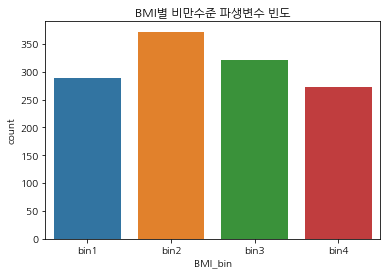

In [123]:
bins = [0, 28.8, 35.17, 39.79, 51]
labels = ['bin1', 'bin2', 'bin3', 'bin4']
dt1['BMI_bin'] = pd.cut(dt1['BMI'], bins=bins, labels=labels) 

sns.countplot(dt1['BMI_bin'] )
plt.title('BMI별 비만수준 파생변수 빈도')
plt.show()

4.  **앙상블을 제외한 분류 알고리즘 3개를 선정하고, 그 이유를 기술하시오.**

- MLP: 인공신경망 기본모델로 input-hidden(여러층 가능)-output layer로 구성되어 비선형 활성화 함수를 적용하여 뛰어난 모델 성능을 보임, 
   모델구조, 데이터에 따라 학습시간이 많이 소요될 수 있으며, 하이퍼파라미터 튜닝이 필요
- SVM: 결정경계(margin)를 최대화하는 초평면을 찾고, 이를 기준으로 분류하는 알고리즘이다. 작은 데이터셋에 강력하며,   
   복잡한 분포도 잘 다룸. 커널 함수로 비선형 문제도 처리가능하며, 일반화 성능이 좋다. 
- Decision Tree(의사결정나무): 트리모형으로 데이터 전처리(정규화, 스케일링)가 거의 필요없으며, 설명력과 시각화에 유리하다.  
   수치형, 범주형 데이터 모두에서 사용 가능하며, 과적합 위험이 있지만 깊이 제한이나 가지치기로 조절 가능

5.  **하이퍼파라미터 튜닝을 실시하고, Precision, Recall을 계산하시오.**

In [124]:
from sklearn.model_selection import train_test_split

Y = dt1['NObeyesdad']
X = dt1.drop(columns='NObeyesdad')

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=0, test_size=0.3)

In [133]:
# one hot
c_cols = train_X.select_dtypes(['O', 'category']).columns
n_cols = train_X.select_dtypes('number').columns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# 거리에 민감한 모델: mlp, svm
preprocess1 = ColumnTransformer(
    transformers= [
        ('num', StandardScaler(), n_cols), 
        ('cat', OneHotEncoder(handle_unknown='ignore'), c_cols)
    ]
)
#이외
preprocess2 = ColumnTransformer(
    transformers= [
        ('cat', OneHotEncoder(handle_unknown='ignore'), c_cols)
    ]
)

In [134]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

mlp_pipe = Pipeline([
    ("preprocess", preprocess1), 
    ("classifier", MLPClassifier())
])

svm_pipe = Pipeline([
    ("preprocess", preprocess1), 
    ("classifier", SVC(probability=True))
])

dt_pipe = Pipeline([
    ("preprocess", preprocess2), 
    ("classifier", DecisionTreeClassifier())
])

In [140]:
from sklearn.metrics import precision_score, recall_score, make_scorer
from sklearn.model_selection import GridSearchCV

t_score = {'precision': make_scorer(precision_score, average='macro'), 
           'recall': make_scorer(recall_score, average='macro')}
# mlp 모델 경사하강법 learning rate(학습률) 조정(0.01~0.2까지 0.02 간격)
param1 = {'classifier__learning_rate_init': np.arange(0.01, 0.2, 0.02)}
# svm 오분류 허용정도(C값이 작으면 많은 오류 허용으로 모델 단순화, 커지면 적은 오류 허용으로 학습데이터에 fit한 모델(과적합 위험))
param2 = {'classifier__C': np.arange(1, 100, 20)}
#cp 파라미터는 가지치기를 통해 decision tree의 크기를 조정하는 파라미터로, 모델의 SSE와 terminal node의 수 간의 trade off를 조정
param3 = {'classifier__ccp_alpha': np.arange(0.1, 1, 0.1)} 

mlp_search = GridSearchCV(
    estimator = mlp_pipe, 
    param_grid = param1, 
    scoring = t_score, 
    cv = 5, 
    refit= 'precision'
)

svm_search = GridSearchCV(
    estimator = svm_pipe, 
    param_grid = param2, 
    scoring = t_score, 
    cv = 5, 
    refit= 'precision'
)

dt_search = GridSearchCV(
    estimator = dt_pipe, 
    param_grid = param3, 
    scoring = t_score, 
    cv = 5, 
    refit= 'precision'
)

for name, model in [('MLP', mlp_search), ('SVM', svm_search), ('Decision Tree', dt_search)]:
    print(f"<모델명: {name}>")
    model.fit(train_X, train_Y)
    print(f"Best param: {model.best_params_}")
    print(f"Best score: {model.best_score_}")

<모델명: MLP>
Best param: {'classifier__learning_rate_init': 0.16999999999999998}
Best score: 0.9965405674464909
<모델명: SVM>
Best param: {'classifier__C': 21}
Best score: 0.9965405674464908
<모델명: Decision Tree>
Best param: {'classifier__ccp_alpha': 0.1}
Best score: 0.9764218635950044


In [143]:
from sklearn.metrics import classification_report, confusion_matrix

dt_list = [(train_X, train_Y), (test_X, test_Y)]
# 모델 예측결과 확인:test, train_set
for name, model in [('MLP', mlp_search), ('SVM', svm_search), ('Decision Tree', dt_search)]:
    print(f"<모델명: {name}>")
    for i, data in enumerate(dt_list):
        if i == 0:
            print("<train set 예측결과>")
        else:
            print("<test set 예측결과>")
        pred = model.predict(data[0])
        cm = pd.DataFrame(confusion_matrix(data[1], pred), index=['실제비만1', '실제비만2', '실제비만3', '실제과체중'], columns=['예측비만1', '예측비만2', '예측비만3', '예측과체중'])
        display(cm)
        print(classification_report(data[1], pred))

<모델명: MLP>
<train set 예측결과>


,예측비만1,예측비만2,예측비만3,예측과체중
실제비만1,238,0,0,0
실제비만2,0,201,0,0
실제비만3,0,0,219,0
실제과체중,0,0,0,219


                    precision    recall  f1-score   support

    obesity_type_i       1.00      1.00      1.00       238
   obesity_type_ii       1.00      1.00      1.00       201
  obesity_type_iii       1.00      1.00      1.00       219
overweight_level_i       1.00      1.00      1.00       219

          accuracy                           1.00       877
         macro avg       1.00      1.00      1.00       877
      weighted avg       1.00      1.00      1.00       877

<test set 예측결과>


,예측비만1,예측비만2,예측비만3,예측과체중
실제비만1,108,1,0,0
실제비만2,1,93,1,0
실제비만3,0,1,102,0
실제과체중,0,0,0,70


                    precision    recall  f1-score   support

    obesity_type_i       0.99      0.99      0.99       109
   obesity_type_ii       0.98      0.98      0.98        95
  obesity_type_iii       0.99      0.99      0.99       103
overweight_level_i       1.00      1.00      1.00        70

          accuracy                           0.99       377
         macro avg       0.99      0.99      0.99       377
      weighted avg       0.99      0.99      0.99       377

<모델명: SVM>
<train set 예측결과>


...

                    precision    recall  f1-score   support

    obesity_type_i       0.99      0.99      0.99       109
   obesity_type_ii       0.99      0.99      0.99        95
  obesity_type_iii       1.00      1.00      1.00       103
overweight_level_i       1.00      1.00      1.00        70

          accuracy                           0.99       377
         macro avg       1.00      1.00      1.00       377
      weighted avg       0.99      0.99      0.99       377

<모델명: Decision Tree>
<train set 예측결과>


,예측비만1,예측비만2,예측비만3,예측과체중
실제비만1,237,1,0,0
실제비만2,22,178,1,0
실제비만3,0,0,219,0
실제과체중,0,0,0,219


                    precision    recall  f1-score   support

    obesity_type_i       0.92      1.00      0.95       238
   obesity_type_ii       0.99      0.89      0.94       201
  obesity_type_iii       1.00      1.00      1.00       219
overweight_level_i       1.00      1.00      1.00       219

          accuracy                           0.97       877
         macro avg       0.98      0.97      0.97       877
      weighted avg       0.97      0.97      0.97       877

<test set 예측결과>


,예측비만1,예측비만2,예측비만3,예측과체중
실제비만1,109,0,0,0
실제비만2,4,91,0,0
실제비만3,0,1,102,0
실제과체중,0,0,0,70


                    precision    recall  f1-score   support

    obesity_type_i       0.96      1.00      0.98       109
   obesity_type_ii       0.99      0.96      0.97        95
  obesity_type_iii       1.00      0.99      1.00       103
overweight_level_i       1.00      1.00      1.00        70

          accuracy                           0.99       377
         macro avg       0.99      0.99      0.99       377
      weighted avg       0.99      0.99      0.99       377



모델 하이퍼 파라미터 튜닝을 train set 을 이용하여 5-Fold, GridSearch 방식으로 학습 후 최적의 파라미터를 다음과 같이 찾아내었다.  
- 모델명: MLP: 경사하강법 학습률(learning_rate 조정)
  - Best param: {'classifier__learning_rate_init': 0.16999999999999998}
  - Best score: 0.9965405674464909
- 모델명: SVM(오차허용율 c조정)
  - Best param: {'classifier__C': 21}
  - Best score: 0.9965405674464908
- 모델명: Decision Tree(모델 크기 조정)
  - Best param: {'classifier__ccp_alpha': 0.1}
  - Best score: 0.9764218635950044
  
test set을 활용하여 모델 성능 측정 결과, 대체로 높은 precision, recall 성능을 보이며, 과적합도 없었다.  
이 중 SVM 모델의 test set의 precision이 1로 가장 높은 성능의 모델로 채택한다.

6.  **위의 결과에 대해서 SOFT VOTING 기법을 적용하고 이전 결과와 비교하시오.**

In [145]:
from sklearn.ensemble import VotingClassifier

soft_voting = VotingClassifier(estimators = [
    ('mlp', mlp_search), 
    ('SVM', svm_search), 
    ('Decision Tree', dt_search)    
], voting='soft')

soft_voting.fit(train_X, train_Y)

VotingClassifier(estimators=[('mlp',
                              GridSearchCV(cv=5,
                                           estimator=Pipeline(steps=[('preprocess',
                                                                      ColumnTransformer(transformers=[('num',
                                                                                                       StandardScaler(),
                                                                                                       Index(['Age', 'Height', 'Weight', 'NCP', 'BMI'], dtype='object')),
                                                                                                      ('cat',
                                                                                                       OneHotEncoder(handle_unknown='ignore'),
                                                                                                       Index(['Gender', 'family_history_with_overweight', 'FAVC', 'FCVC', 'CAEC'

In [146]:
for i, data in enumerate(dt_list):
    if i == 0:
        print("<train set 예측결과>")
    else:
        print("<test set 예측결과>")
    pred = soft_voting.predict(data[0])
    cm = pd.DataFrame(confusion_matrix(data[1], pred), index=['실제비만1', '실제비만2', '실제비만3', '실제과체중'], columns=['예측비만1', '예측비만2', '예측비만3', '예측과체중'])
    display(cm)
    print(classification_report(data[1], pred))

<train set 예측결과>


,예측비만1,예측비만2,예측비만3,예측과체중
실제비만1,238,0,0,0
실제비만2,0,201,0,0
실제비만3,0,0,219,0
실제과체중,0,0,0,219


                    precision    recall  f1-score   support

    obesity_type_i       1.00      1.00      1.00       238
   obesity_type_ii       1.00      1.00      1.00       201
  obesity_type_iii       1.00      1.00      1.00       219
overweight_level_i       1.00      1.00      1.00       219

          accuracy                           1.00       877
         macro avg       1.00      1.00      1.00       877
      weighted avg       1.00      1.00      1.00       877

<test set 예측결과>


,예측비만1,예측비만2,예측비만3,예측과체중
실제비만1,109,0,0,0
실제비만2,1,94,0,0
실제비만3,0,1,102,0
실제과체중,0,0,0,70


                    precision    recall  f1-score   support

    obesity_type_i       0.99      1.00      1.00       109
   obesity_type_ii       0.99      0.99      0.99        95
  obesity_type_iii       1.00      0.99      1.00       103
overweight_level_i       1.00      1.00      1.00        70

          accuracy                           0.99       377
         macro avg       1.00      0.99      1.00       377
      weighted avg       0.99      0.99      0.99       377



SVM 모델은 precision과 recall 값이 1로 매우 높게 나타났다.  
반면, soft voting 방식은 test 세트에서 precision과 recall이 0.99로 소폭 낮아졌으며, 이는 세 모델의 예측을 평균화함으로써  
과적합은 줄고 일반화 성능이 향상되었음을 보여준다.

7.  **하나의 모델을 선정하여 Feature importance와 Drop column importance를 활용하여 변수를 선택하시오.**

| 항목         | Drop Column Importance     | Permutation Importance          |
| ---------- | -------------------------- | ------------------------------- |
| **방법**     | 변수를 **아예 제거**한 후 모델을 다시 학습 | 변수 값을 **무작위로 섞어** 성능 변화를 측정     |
| **학습**     | 변수 제거 후 **다시 학습**          | 기존 모델 그대로, 테스트셋에서만 **예측 변화 측정** |
| **비용(시간)** | 느림 (모델 N번 재학습)             | 빠름 (한 번 학습한 모델로 평가만 반복)         |
| **해석**     | 해당 변수가 모델 학습에 얼마나 중요했는지    | 해당 변수가 예측에 얼마나 기여했는지            |
| **영향력 평가** | 학습 과정에서의 중요도 반영            | 예측 단계에서의 중요도만 반영                |
| **과적합 영향** | 적음 (매번 학습하므로 일반화 반영)       | 높을 수 있음 (기존 모델 그대로 사용)          |


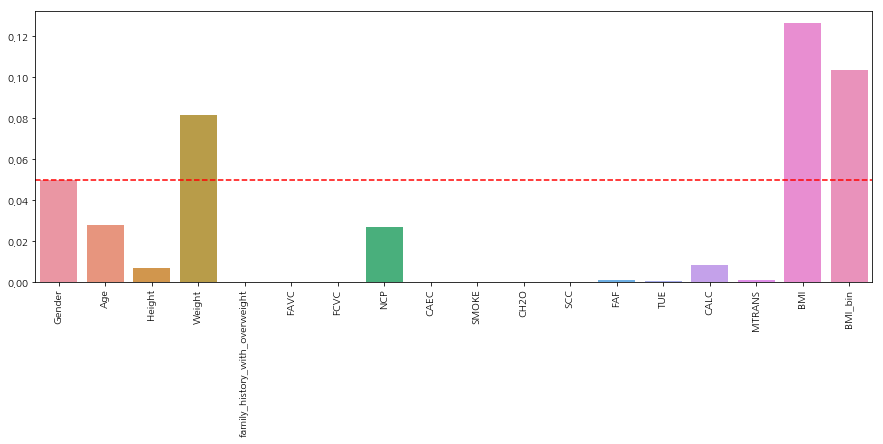

In [156]:
from sklearn.inspection import permutation_importance

f_imp = permutation_importance(svm_search, train_X, train_Y, n_repeats=10, random_state=42)

feat = train_X.columns
imp = f_imp.importances_mean

plt.figure(figsize=(15, 5))
sns.barplot(x=feat, y=imp)
plt.xticks(rotation=90)
plt.axhline(y=0.05, color='r', linestyle='--')
plt.show()


예측 단계에서 모델의 영향력 기여율이 5% 이상인 3개 변수(weight, BMI, BMI_bins)를 선택한다.

In [178]:
full_model_score = svm_search.best_estimator_.score(train_X, train_Y)
drop_col_importances = {} #컬럼을 하나씩 삭제했을 때 importance

for col in train_X.columns:
    temp_X = train_X.drop(columns=col)
    c_cols1 = temp_X.select_dtypes(['O', 'category']).columns
    n_cols1 = temp_X.select_dtypes('number').columns
    
    preprocess3 = ColumnTransformer(
    transformers= [
        ('num', StandardScaler(), n_cols1), 
        ('cat', OneHotEncoder(handle_unknown='ignore'), c_cols1)])
    
    reduce_model = Pipeline([
    ("preprocess", preprocess3), 
    ("classifier", SVC(probability=True))])
    
    reduce_model.fit(temp_X, train_Y)
    drop_col_importances[col] = full_model_score - reduce_model.score(temp_X, train_Y) #두 모델의 성능차

In [179]:
tt = pd.Series(drop_col_importances)
dci_score = (tt - tt.min())/(tt.max()-tt.min())#정규화
dci_score.sort_values(ascending=False)

Age                               1.000000
NCP                               0.500000
FCVC                              0.333333
CALC                              0.333333
Height                            0.333333
Weight                            0.333333
CH2O                              0.333333
BMI                               0.333333
BMI_bin                           0.166667
family_history_with_overweight    0.166667
FAVC                              0.166667
CAEC                              0.166667
SMOKE                             0.166667
SCC                               0.166667
FAF                               0.166667
MTRANS                            0.166667
Gender                            0.166667
TUE                               0.000000
dtype: float64

Drop column importance 시행결과, 학습단계에서 Age, NCP의 변수 중요도가 높음을 알 수 있다.  
TUE는 0으로 중요하지 않은 변수임을 알 수 있다. 

| 상황             | 해석                                        |
| -------------- | ----------------------------------------- |
| `차이 > 0`       | 해당 변수를 빼면 성능이 떨어졌음 → 그 변수는 **중요함**        |
| `차이 ≈ 0`       | 빼도 성능 변화 거의 없음 → 그 변수는 **중요하지 않음**        |
| `차이 < 0` (드물게) | 뺐더니 성능이 좋아짐 → 해당 변수는 **잡음(noise)** 일 수 있음 |


## 문제 2

**Data description**

개인의 건강검진 데이터를 활용하여 다음 문제를 해결하시오.

-   **ID**

-   **키**

-   **weight**

-   **생년월일**

-   **건강검진일**

-   **공학여부**

-   **채소섭취정도**

-   **아침식사여부**

-   **일주일운동시간**

-   **수면시간**

-   **성별**

1.  **위 표를 바탕으로 파생변수(적정체중 여부)를 도출하고, 만나이와 파생변수(적정체중 여부)의 빈도표를 산출하시오.**

-   만나이 : (검진날짜 - 생년월일)/365, 소수점 버림

-   BMI : $\frac{몸무게}{키^2}$ (키는 m 기준), 소수점 둘째자리 반올림

|      | 16세         | 17세         |
|------|--------------|--------------|
| 남자 | 17.3 \~ 18.4 | 17.8 \~ 20.4 |
| 여자 | 16.7 \~ 18.7 | 16.7 \~ 18.7 |

: 성별과 만나이에 따른 BMI 기준표(적정 체중 기준)

|      | YES | NO  |
|------|-----|-----|
| 16세 | 00  | 00  |
| 17세 | 00  | 00  |

: 빈도표 예시

In [190]:
dt2 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/31/problem2.csv')

dt2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6801 entries, 0 to 6800
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       6801 non-null   object 
 1   키        6801 non-null   float64
 2   weight   6801 non-null   float64
 3   생년월일     6801 non-null   int64  
 4   건강검진일    6801 non-null   object 
 5   공학여부     6801 non-null   int64  
 6   채소섭취정도   6801 non-null   int64  
 7   아침식사여부   6801 non-null   int64  
 8   일주일운동시간  6801 non-null   float64
 9   수면시간     6801 non-null   float64
 10  성별       6801 non-null   object 
dtypes: float64(4), int64(4), object(3)
memory usage: 584.6+ KB


In [191]:
dt2.head(3)

,ID,키,weight,생년월일,건강검진일,공학여부,채소섭취정도,아침식사여부,일주일운동시간,수면시간,성별
0,ID_4135,169.01,65.47,20041003,2020_11_15,1,2,1,4.4,8.3,남성
1,ID_3289,181.62,69.36,19970725,2014_11_20,0,3,0,4.4,6.9,남성
2,ID_1847,160.89,65.12,20020921,2020_01_28,1,1,1,1.7,9.6,여성


In [194]:
dt2[['공학여부', '채소섭취정도', '아침식사여부']] = dt2[['공학여부', '채소섭취정도', '아침식사여부']].astype('O')

In [192]:
from datetime import datetime

dt2['생년월일'] = pd.to_datetime(dt2['생년월일'], format='%Y%m%d') #최초 형식에 맞게
dt2['건강검진일'] = dt2['건강검진일'].str.replace('_', "")
dt2['건강검진일'] = pd.to_datetime(dt2['건강검진일'], format='%Y-%m-%d')

#만나이 계산
dt2['만나이'] = ((dt2['건강검진일']-dt2['생년월일']).dt.days / 365).astype(int)
#bmi
dt2['BMI'] = round(dt2['weight']/((dt2['키']/100)**2), 1)

dt2.head(3)

,ID,키,weight,생년월일,건강검진일,공학여부,채소섭취정도,아침식사여부,일주일운동시간,수면시간,성별,만나이,BMI
0,ID_4135,169.01,65.47,2004-10-03,2020-11-15,1,2,1,4.4,8.3,남성,16,22.9
1,ID_3289,181.62,69.36,1997-07-25,2014-11-20,0,3,0,4.4,6.9,남성,17,21.0
2,ID_1847,160.89,65.12,2002-09-21,2020-01-28,1,1,1,1.7,9.6,여성,17,25.2


In [195]:
cond1 = (dt2['성별']=='남성') & (dt2['만나이']==16) & (dt2['BMI'].between(17.3, 18.4))
cond2 = (dt2['성별']=='남성') & (dt2['만나이']==17) & (dt2['BMI'].between(17.8, 20.4))
cond3 = (dt2['성별']=='여성') & (dt2['만나이']==16) & (dt2['BMI'].between(16.7, 18.7))
cond4 = (dt2['성별']=='여성') & (dt2['만나이']==17) & (dt2['BMI'].between(16.7, 18.7))

dt2['적정체중여부'] = np.where(cond1|cond2|cond3|cond4, 'YES', 'NO')

f_tab = pd.crosstab(dt2['만나이'], dt2['적정체중여부'])

display(f_tab)

적정체중여부,NO,YES
만나이,,
16,2981,134
17,3343,343


In [197]:
#불필요 변수 삭제
dt2.drop(columns=['ID', '키', 'weight', '생년월일', '건강검진일', '만나이', 'BMI', '건강검진일'], inplace=True)
dt2.head(2)

,공학여부,채소섭취정도,아침식사여부,일주일운동시간,수면시간,성별,적정체중여부
0,1,2,1,4.4,8.3,남성,NO
1,0,3,0,4.4,6.9,남성,NO


2.  **파생변수(적정체중 여부)와 기존 변수와의 유의성 확인하시오.**

- 범주형 변수와 파생변수(범주형) 간 유의성 확인: 카이제곱 독립성 검정
- 연속형 변수와 파생변수(범주형) 간 유의성 확인: 독립검정 ttest

- 가설설정
  - H0: 파생변수와 독립변수 간 통계적으로 유의미한 관계가 없다.(독립적이다.)
  - H1: 파생변수와 독립변수 간 통계적으로 유의미한 관계가 있다.(영향을 미친다.)

In [207]:
c_cols = dt2.select_dtypes('O').columns[:-1]
n_cols = dt2.select_dtypes('number').columns

rs = pd.DataFrame(columns=['변수명', '통계량', 'p-value', '귀무가설 기각'])

from scipy.stats import chi2_contingency, ttest_ind

for col in c_cols:
    c_tab = pd.crosstab(dt2['적정체중여부'], dt2[col])
    c_stat, p, dof, expected = chi2_contingency(c_tab)
    dc = ['X' if p > 0.05 else 'O']
    rs.loc[len(rs)] = [col, c_stat, p, dc]

for col in n_cols:
    g1 = dt2[dt2['적정체중여부']=='YES'][col]
    g2 = dt2[dt2['적정체중여부']=='NO'][col]
    t_stat, p = ttest_ind(g1, g2)
    dc = ['X' if p > 0.05 else 'O']
    rs.loc[len(rs)] = [col, t_stat, p, dc]
rs

,변수명,통계량,p-value,귀무가설 기각
0,공학여부,2.028952,0.154327,[X]
1,채소섭취정도,3.162001,0.531090,[X]
2,아침식사여부,0.618251,0.431698,[X]
3,성별,0.134181,0.714135,[X]
4,일주일운동시간,-0.201769,0.840103,[X]
5,수면시간,-0.354325,0.723107,[X]


독립성 검정결과, 유의수준 5% 하에서 모든 변수의 p-value가 0.05보다 크므로 모든 변수에서의 귀무가설을 기각할 수 없다.  
따라서 파생변수와 독립변수들 간 통계적으로 유의미한 관계가 없다.(독립적이다.)

3.  **Logistic regression과 XGBoost 모형을 적합하시오.**

    **(위 문제에서 통계적으로 유의한 변수를 활용하여) 구문 제거 –\> 문제 수정**

In [227]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

Y = dt2['적정체중여부']
X = dt2.drop(columns='적정체중여부')
train_X, test_X, train_Y, test_Y = train_test_split(X, Y, test_size=0.3, random_state=0)
train_X.shape, test_X.shape

((4760, 6), (2041, 6))

In [228]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

cc = train_X.columns.to_list()
snt = '+'.join(cc)
train = pd.concat([train_X, train_Y], axis=1)

logit_model = sm.formula.glm(formula=f"적정체중여부~{snt}", family=sm.families.Binomial(), data=train).fit()

In [229]:
#로지스틱에서는 모델 스케일링 맞춰줌
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
train_X1 = train_X.copy()
test_X1 = test_X.copy()
train_X1[n_cols] = sc.fit_transform(train_X1[n_cols])
test_X1[n_cols] = sc.transform(test_X1[n_cols])

train_X = pd.get_dummies(train_X, columns=c_cols)
train_X1 = pd.get_dummies(train_X1, columns=c_cols)
test_X = pd.get_dummies(test_X, columns=c_cols)
test_X1 = pd.get_dummies(test_X1, columns=c_cols)

In [232]:
train_Y = np.where(train_Y == 'YES', 1, 0)
test_Y = np.where(test_Y == 'YES', 1, 0)

In [237]:
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

lr = LogisticRegression()
xgb = XGBClassifier()

lr.fit(train_X1, train_Y)
xgb.fit(train_X, train_Y)

XGBClassifier()

In [242]:
# 로지스틱
pred1 = lr.predict(train_X1)
pred2 = lr.predict(test_X1)
auc1 = roc_auc_score(train_Y, pred1)
auc2 = roc_auc_score(test_Y, pred2)
print("<Logistic Regression model: train>")
print(f"auc score: {auc1:.3f}")
print(classification_report(train_Y, pred1))
print("<Logistic Regression model: test>")
print(f"auc score: {auc2:.3f}")
print(classification_report(test_Y, pred2))

# xgb
pred3 = xgb.predict(train_X)
pred4 = xgb.predict(test_X)
auc3 = roc_auc_score(train_Y, pred3)
auc4 = roc_auc_score(test_Y, pred4)
print("<XGB classifier model: train>")
print(f"auc score: {auc3:.3f}")
print(classification_report(train_Y, pred3))
print("<XGB classifier model: test>")
print(f"auc score: {auc4:.3f}")
print(classification_report(test_Y, pred4))

<Logistic Regression model: train>
auc score: 0.500
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      4424
           1       0.00      0.00      0.00       336

    accuracy                           0.93      4760
   macro avg       0.46      0.50      0.48      4760
weighted avg       0.86      0.93      0.90      4760

<Logistic Regression model: test>
auc score: 0.500
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      1900
           1       0.00      0.00      0.00       141

    accuracy                           0.93      2041
   macro avg       0.47      0.50      0.48      2041
weighted avg       0.87      0.93      0.90      2041

<XGB classifier model: train>
auc score: 0.500
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      4424
           1       0.00      0.00      0.00       336

    accuracy                    

4.  **회귀계수에 대해 오즈비로 해석하고, 통계적 유의성을 확인하시오.**

In [243]:
print(logit_model.summary())

                       Generalized Linear Model Regression Results                       
Dep. Variable:     ['적정체중여부[NO]', '적정체중여부[YES]']   No. Observations:                 4760
Model:                                       GLM   Df Residuals:                     4750
Model Family:                           Binomial   Df Model:                            9
Link Function:                             Logit   Scale:                          1.0000
Method:                                     IRLS   Log-Likelihood:                -1211.3
Date:                           Mon, 07 Jul 2025   Deviance:                       2422.6
Time:                                   20:38:48   Pearson chi2:                 4.76e+03
No. Iterations:                                6   Pseudo R-squ. (CS):           0.001361
Covariance Type:                       nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------

In [245]:
# 통계적으로 유의할 시 오즈비 해석
np.exp(logit_model.params)

Intercept      12.391659
공학여부[T.1]       1.157291
채소섭취정도[T.1]     0.871960
채소섭취정도[T.2]     0.884028
채소섭취정도[T.3]     0.875156
채소섭취정도[T.4]     0.727164
아침식사여부[T.1]     0.888080
성별[T.여성]        0.999568
일주일운동시간         1.007254
수면시간            1.021973
dtype: float64

통계적으로 유의한 설명변수 없음(p-value 0.05 이상)  
통계적으로 유의한 변수가 있을 시 오즈비 해석

| 변수명           | 오즈비 (OR) | 해석                                                       |
| ------------- | -------- | -------------------------------------------------------- |
| `공학여부[T.1]`   | 1.16     | 공학 전공자는 비공학 전공자보다 종속변수 발생 가능성이 약 **1.16배** 높음            |
| `채소섭취정도[T.1]` | 0.87     | T.1 그룹은 기준 그룹에 비해 결과 발생 가능성이 **13% 낮음**                  |
| `채소섭취정도[T.2]` | 0.88     | 결과 발생 가능성이 **12% 낮음**                                    |
| `채소섭취정도[T.3]` | 0.88     | 결과 발생 가능성이 **12% 낮음**                                    |
| `채소섭취정도[T.4]` | 0.73     | 결과 발생 가능성이 **27% 낮음**                                    |
| `아침식사여부[T.1]` | 0.89     | 아침 식사하는 사람은 안 하는 사람보다 결과 발생 가능성이 **11% 낮음**              |
| `성별[T.여성]`    | 1.00     | 남성과 여성 간 **차이가 거의 없음** (OR ≈ 1)                          |
| `일주일운동시간`     | 1.007    | 운동 시간이 1시간 늘면 결과 발생 가능성이 **약 0.7% 증가**                   |
| `수면시간`        | 1.022    | 수면이 1시간 늘면 결과 발생 가능성이 **약 2.2% 증가**                      |


5.  **두 모형의 ROC curve를 시각화하시오(겹쳐그릴 것).**

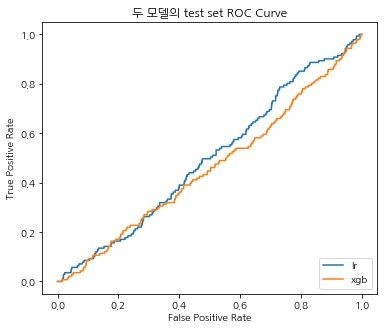

In [249]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
from sklearn.metrics import plot_roc_curve
#test set 기준 roc curve
roc_lr = plot_roc_curve(lr, test_X1, test_Y, ax=ax, label='lr')
roc_xgb = plot_roc_curve(xgb, test_X, test_Y, ax=ax, label='xgb')
ax.set_title("두 모델의 test set ROC Curve")
plt.show()

Test set에서 두 모델의 ROC Curve를 비교한 결과, 두 곡선 모두 좌측 상단으로 충분히 치우치지 못한 형태를 보였습니다.  
일반적으로 ROC Curve는 곡선이 좌측 상단에 가까울수록 모델의 성능이 우수하며, 이 곡선 아래 면적인 AUC (Area Under the Curve) 값이 1에   
가까울수록 분류 성능이 뛰어납니다.  
하지만 이번 결과에서는 두 모델 모두 AUC 값이 약 0.5로, 무작위 추측과 큰 차이가 없는 수준의 낮은 성능을 보였습니다.

- AUC = 0.5 → 동전 던지기 수준 (random)
- AUC ≥ 0.7 → 의미 있는 성능
- AUC ≥ 0.9 → 매우 뛰어난 모델

## 문제 3


**평균이 (**$\theta$**)이고 분산이 100인 정규분포 (**$\mathcal{N}(\theta, 100)$**)에서 사전분포로 평균이 100, 분산이 256인 정규분포 (**$\mathcal{N}(100, 256)$**)를 사용합니다. 이때, 관측된 데이터 (**$x = 120$**)일 경우 사후분포의 평균을 구하시오.**

::: callout-note
켤레 사전분포족(conjugate prior family)

베이즈 추론에서 사후분포는 사전분포와 데이터를 통해 얻어진 우도 함수를 결합하여 구해집니다. 켤레 사전분포는 다음과 같은 성질을 가집니다

-   사전분포가 특정한 분포족에 속할 때, 우도 함수와 결합된 사후분포도 동일한 분포족에 속한다.

    분포 표 예시 : <https://en.wikipedia.org/wiki/Conjugate_prior>

이를 통해 계산이 간단해지고, 해석이 직관적이 됩니다.
:::

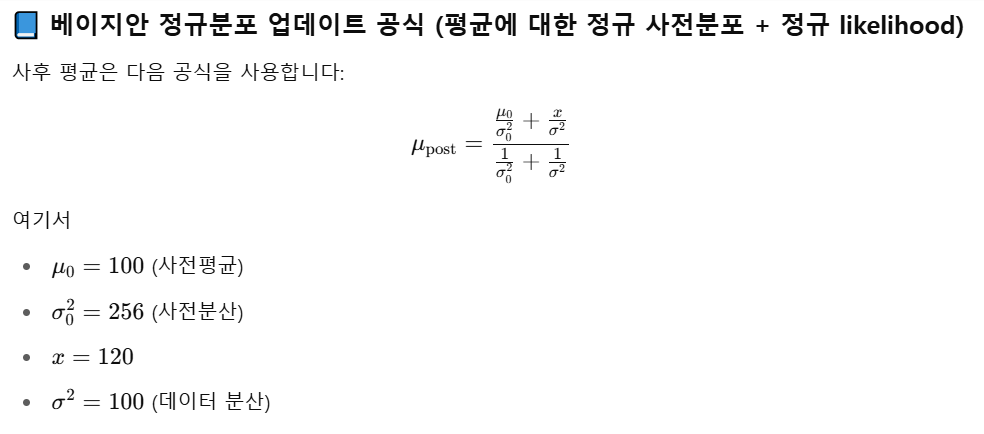

In [75]:
u0 = 100 #사전평균
v0 = 256 #사전분산
x = 120 # 관측값
v = 100 #데이터 분산

rs = ((u0/v0)+(x/v))/((1/v0)+(1/v))

print(f"사후분포의 평균: {rs}")

사후분포의 평균: 114.3820224719101


## 문제 4

**Data description**

-   **TV_Ad_Budget** : TV 광고 예산

-   **Radio_Ad_Budget** : 라디오 광고 예산

-   **Newspaper_Ad_Budget** : 신문 광고 예산

-   **Sales** : 판매 수익

1.  **선형 회귀 모델을 적합한 후 통계적 유의성을 검토하시오.**

In [76]:
dt4 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/31/problem4.csv')

In [81]:
import statsmodels.formula.api as smf

model = smf.ols('Sales~TV_Ad_Budget+Radio_Ad_Budget+Newspaper_Ad_Budget', data=dt4).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Mon, 07 Jul 2025   Prob (F-statistic):           1.58e-96
Time:                        15:20:39   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               2.9389    

- 가설설정
  - H0: 판매수익과 각 독립변수 간에는 통계적으로 유의미한 영향이 없다.
  - H1: 판매수익과 적어도 하나의 독립변수 간에는 통계적으로 유의미한 영향이 있다.
- 해석  
F검정을 활용한 선형회귀 모델 분석결과를 보면, 유의수준 5% 하에서 Newspaper_Ad_Budget은 p-value 0.860로 0.05보다 크므로  
귀무가설을 기각할 수 없다. 나머지 두 변수는 p-value가 0으로 충분히 작으므로  귀무가설을 기각한다.  
따라서, 라디오 광고예산과 TV 광고예산은 판매수익에 통계적으로 유의미한 영향을 미친다.  
(두 광고예산이 늘수록 판매수익 증가)

2.  **변수 선택시에 먼저 제거가 될 변수를 파악하고, 근거를 제시하시오.**

- 상관관계가 매우 낮은 변수 (독립변수 vs 종속변수 간)
- 다중공선성이 높은 변수 (VIF가 높은 경우)
- 결측치가 많은 변수
- 분산이 거의 없는 변수
- 도메인 지식에 기반한 불필요한 변수

위 회귀분석 결과, Newspaper_Ad_Budget는 판매수익과 유의미한 영향이 없었으며 계수 또한 0에 가까운 값을 가진다.   
또한 선형 상관관계 분석에서도 판매수익과 낮은 상관관계를 가지므로 제거한다.

In [85]:
dt4.corr()['Sales']

TV_Ad_Budget           0.782224
Radio_Ad_Budget        0.576223
Newspaper_Ad_Budget    0.228299
Sales                  1.000000
Name: Sales, dtype: float64

In [88]:
dt4.drop(columns='Newspaper_Ad_Budget', inplace=True)

-   **분산팽창계수(VIF)를 활용하여 다중공선성을 진단하시오.**

In [89]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


x = add_constant(dt4[dt4.columns[:-1]])
vif_df = pd.DataFrame()
vif_df['feat'] = x.columns
vif_df['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

vif_df

,feat,VIF
0,const,6.135476
1,TV_Ad_Budget,1.003013
2,Radio_Ad_Budget,1.003013


두 변수 모두 vif가 1에 가까우므로 다중공선성이 존재하지 않는다.

## 문제 5

회사에서는 3개의 다른 마케팅 캠페인(캠페인 A, 캠페인 B, 캠페인 C)을 실행하여 고객에게 이메일을 발송했습니다. 각 캠페인 후, 고객이 제품을 구매했는지 여부를 기록했습니다. 다음 데이터는 15명의 고객에 대해 각 캠페인에 대한 구매 여부(1: 구매, 0: 미구매)를 나타낸 것입니다.

**각 마케팅 캠페인(A, B, C)의 구매 효과의 차이가 있는지 여부를 검정하시오.**

::: callout-note
-   독립 표본에 대한 범주형 변수 간의 관계 검정 : 카이제곱 검정
-   대응 표본에 대한 범주형 변수 간의 관계 검정 : 코크란 Q 검정(세 그룹 이상일 때)
:::

| 검정 이름                   | 조건                         | 사용 여부         |
| ----------------------- | -------------------------- | ------------- |
| **Friedman test**       | 세 개 이상의 **대응표본** & 연속형/서열형 | ✅ 적합 (비모수 대안) |
| Cochran's Q test        | 세 개 이상의 **이진 대응표본**        | ✅ **가장 적절함**  |
| Repeated Measures ANOVA | 대응표본 & 정규성 가정              | ❌ 이진데이터라 부적합  |

In [91]:
dt5 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/31/problem5.csv')
dt5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Customer    15 non-null     object
 1   Campaign_A  15 non-null     int64 
 2   Campaign_B  15 non-null     int64 
 3   Campaign_C  15 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 608.0+ bytes


In [94]:
dt5.head(3)

,Customer,Campaign_A,Campaign_B,Campaign_C
0,Customer 1,1,0,0
1,Customer 2,0,1,1
2,Customer 3,1,1,0


In [97]:
# 코크란 이진 대응표본 검정
#귀무가설: 마케팅 캠페인은 모두 동일한 구매효과를 가진다.
#대립가설: 마케팅 캠페인 중 적어도 하나는 구매효과의 차이가 있다.
from statsmodels.stats.contingency_tables import cochrans_q

dt5.drop(columns='Customer', inplace=True)

result = cochrans_q(dt5)
stat, p = result.statistic, result.pvalue

print(f"코크란 이진 대응표본 검정결과: p-value {p:.3f}로 귀무가설을 ", "기각" if p < 0.05 else "기각x")

코크란 이진 대응표본 검정결과: p-value 0.913로 귀무가설을  기각x


유의수준 5% 하에서 귀무가설을 기각하지 못하므로, 세 캠페인의 구매효과는 동일하며 차이가 없다.

## 문제 6

별도의 데이터 없음

어떤 웹사이트는 매시간 평균 4명의 방문자가 들어옵니다. 이 웹사이트에 대해 다음 질문에 답하시오.

::: callout-note
특정 시간 동안 발생한 사건의 건수는 포아송분포를 따름

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$
:::

1.  **한 시간 동안 방문자가 한 명도 없을 확률을 계산하시오.**

$$
P(X = 0) = \frac{4^0 e^{-4}}{0!} = e^{-4} = 0.0183
$$

In [73]:
from scipy.stats import poisson
lam = 4

prob_0 = poisson.pmf(0, lam)

print(f"한 시간동안 방문자가 한명도 없을 확률: {prob_0:.4f}")

한 시간동안 방문자가 한명도 없을 확률: 0.0183


2.  **한 시간 동안 방문자가 5명 이상일 확률을 계산하시오.**

$$
\begin{aligned}
&P(X < 5) = P(X = 0) + P(X = 1) + P(X = 2) + P(X = 3) + P(X = 4) = 0.6289 \\
&P(X \geq 5) = 1 - P(X < 5) = 0.3711
\end{aligned}
$$

In [74]:
#1-4명 이하
prob_4 = poisson.cdf(4, lam)
rs = 1-prob_4
print(f"한 시간동안 방문자가 5명 이상일 확률: {rs:.4f}")

한 시간동안 방문자가 5명 이상일 확률: 0.3712
